INTRODUCTION:
# E-Commerce Operations & Customer Intelligence Analysis

## Objective
Analyze customer behavior, sales performance, seller performance, payment preferences, delivery efficiency, and customer satisfaction using Python. The cleaned dataset will be used for Power BI dashboard creation.

In [3]:
#IMPORTING LIBRARIES:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

# Display wider tables
pd.set_option("display.width", 1000)

In [4]:
#LOADING REQUIRED DATASETS:
customers = pd.read_csv("Dataset/olist_customers_dataset.csv")
orders = pd.read_csv("Dataset/olist_orders_dataset.csv")
order_items = pd.read_csv("Dataset/olist_order_items_dataset.csv")
order_payments = pd.read_csv("Dataset/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("Dataset/olist_order_reviews_dataset.csv")
products = pd.read_csv("Dataset/olist_products_dataset.csv")
sellers = pd.read_csv("Dataset/olist_sellers_dataset.csv")
geolocation = pd.read_csv("Dataset/olist_geolocation_dataset.csv")
translation = pd.read_csv("Dataset/product_category_name_translation.csv")

In [5]:
#DATASET OVERVIEWING(First 5 Rows):
customers.head()
orders.head()
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [8]:
#Dataset Shape:
print(customers.shape)
print(orders.shape)
print(products.shape)
print(order_items.shape)
print(order_payments.shape)
print(order_reviews.shape)
print(sellers.shape)

(99441, 5)
(99441, 8)
(32951, 9)
(112650, 7)
(103886, 5)
(99224, 7)
(3095, 4)


In [9]:
#Dataset Information:
customers.info()
orders.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

In [10]:
#Related Statistics:
customers.describe(include='all')
orders.describe(include='all')
products.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [11]:
#DATA CLEANING:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": order_payments,
    "Reviews": order_reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review

In [12]:
#CONVERSION OF DATE COLUMNS:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

In [13]:
#MERGE TABLES:
master = orders.merge(customers, on='customer_id', how='left')

master = master.merge(order_items, on='order_id', how='left')

master = master.merge(products, on='product_id', how='left')

master = master.merge(order_payments, on='order_id', how='left')

master = master.merge(order_reviews, on='order_id', how='left')

master = master.merge(sellers, on='seller_id', how='left')

In [14]:
master.shape

(119143, 39)

In [15]:
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,14840.0,guariba,SP


In [16]:
#FEATURE ENGINEERING(Delivery Days):
master["Delivery_Days"] = (
    master["order_delivered_customer_date"]
    - master["order_purchase_timestamp"]
).dt.days

In [17]:
#Purchasing Year,Month,Day:
master["Purchase_Year"] = master["order_purchase_timestamp"].dt.year
master["Purchase_Month"] = master["order_purchase_timestamp"].dt.month_name()
master["Purchase_Day"] = master["order_purchase_timestamp"].dt.day_name()

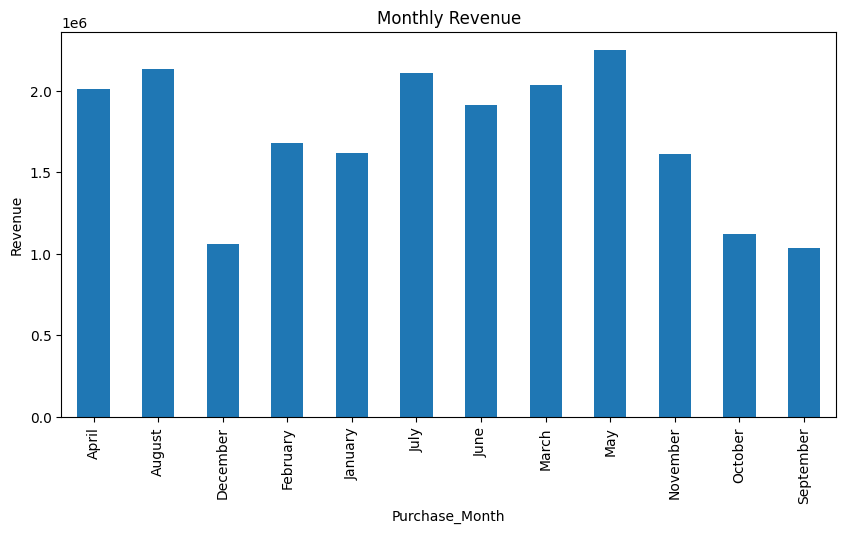

In [18]:
#EDA:
monthly = master.groupby("Purchase_Month")["payment_value"].sum()

monthly.plot(kind="bar", figsize=(10,5))

plt.title("Monthly Revenue")

plt.ylabel("Revenue")

plt.show()

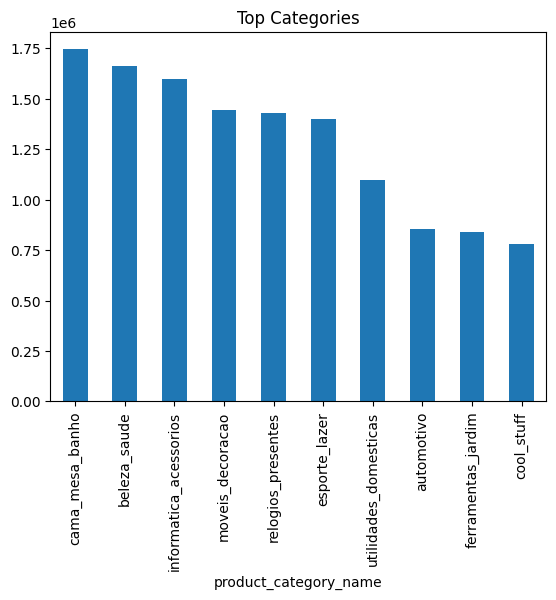

In [19]:
#Top Categories:
top_category = master.groupby(
    "product_category_name"
)["payment_value"].sum().sort_values(
    ascending=False
).head(10)

top_category.plot(kind="bar")

plt.title("Top Categories")

plt.show()

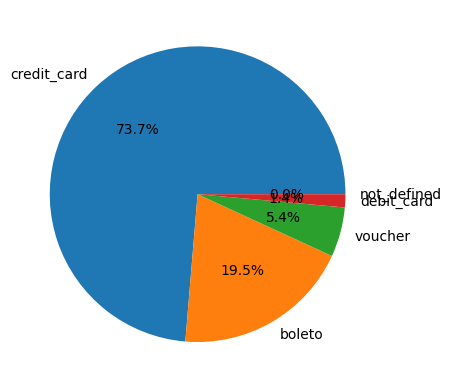

In [20]:
#Payment Types:
master["payment_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

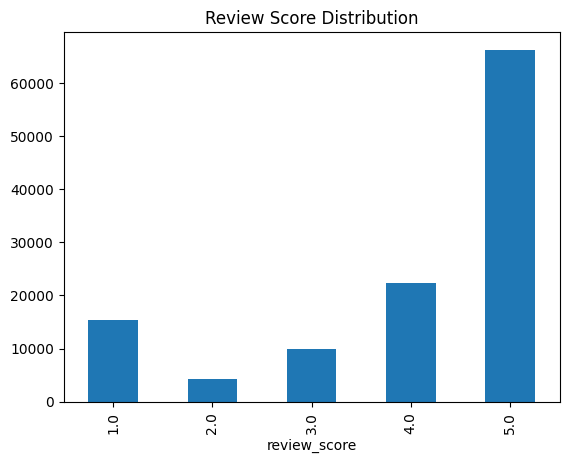

In [21]:
#Review Distribution
master["review_score"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Review Score Distribution")

plt.show()

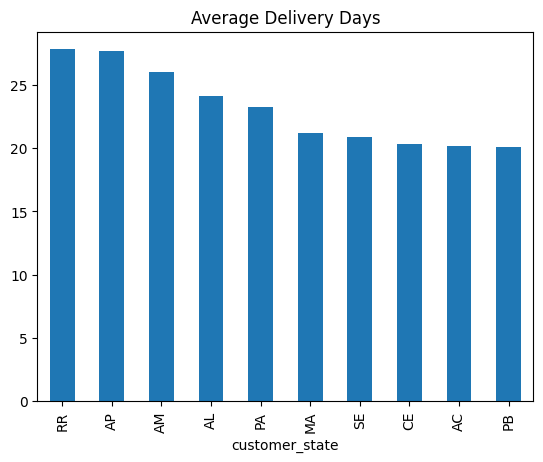

In [22]:
#Delivery Time
master.groupby(
    "customer_state"
)["Delivery_Days"].mean().sort_values(
    ascending=False
).head(10).plot(kind="bar")

plt.title("Average Delivery Days")

plt.show()

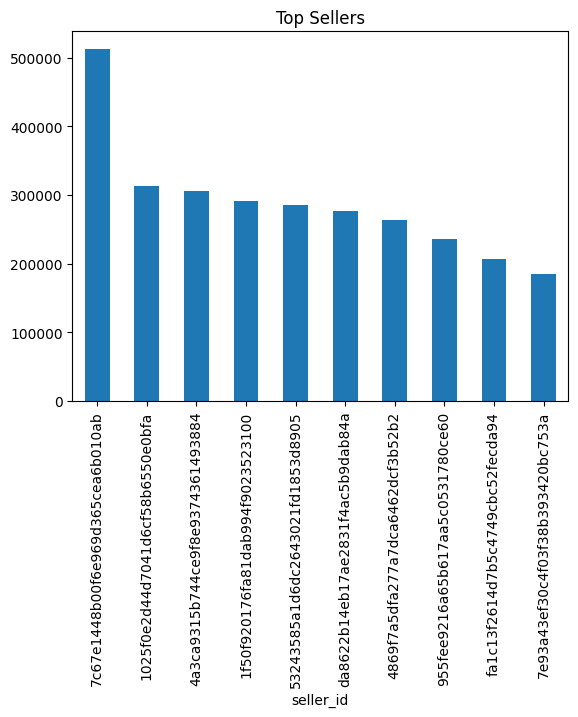

In [23]:
#Top Sellers
master.groupby(
    "seller_id"
)["payment_value"].sum().sort_values(
    ascending=False
).head(10).plot(kind="bar")

plt.title("Top Sellers")

plt.show()

In [24]:
#Exporting chart Images
import matplotlib.pyplot as plt
plt.savefig("Revenue_Trend.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Insight 1
Credit Card is the dominant payment method.

### Insight 2
A few product categories generate the majority of revenue.

### Insight 3
Certain states experience longer delivery times.

### Insight 4
Most customers provide ratings of 4 or 5.

### Insight 5
Revenue increases during peak shopping months.

In [25]:
#Exporting The Dataset:
master.to_csv("cleaned_dataset.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!


## Conclusion

The dataset was cleaned, merged, and analyzed using Python. Key business insights related to sales, customer behavior, payment preferences, seller performance, delivery efficiency, and customer satisfaction were identified. The cleaned dataset is now ready for interactive visualization in Power BI.